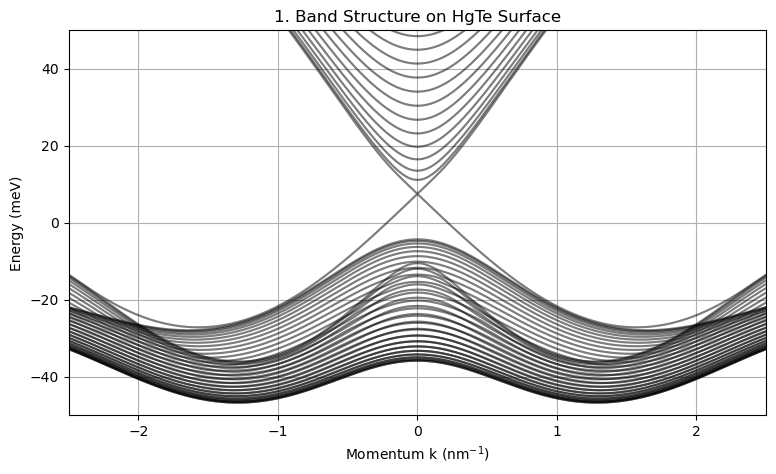

In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Ignorar advertencias para limpieza
warnings.filterwarnings("ignore")

# Definición del Hamiltoniano BHZ (4x4)
hamiltonian_bhz = """
 (C + M - B * (k_x**2 + k_y**2)) * kron(sigma_0, sigma_z) 
 - D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
 + A * k_x * kron(sigma_z, sigma_x) 
 - A * k_y * kron(sigma_0, sigma_y)
"""

a=7 # 'nm'
def make_system(L=400, W=300, a=a):
    """
    Construye un sistema de nanocinta de HgTe.
    """
    # Parámetros (Aseguramos que sean floats) Parámetros verificados (König et al. 2008, 7nm HgTe QW)
    params = dict(A=364.5, B=-686.0, D=-512.0, M=-10.0, C=0.0)
    
    # 1. Discretización automática
    template = kwant.continuum.discretize(hamiltonian_bhz, grid=a)
    
    # 2. Definición de la red y el constructor
    lat = kwant.lattice.square(a)
    syst = kwant.Builder()
    
    # 3. Relleno de la región de dispersión
    def shape(site):
        (x, y) = site.pos
        return 0 <= x < L and 0 <= y < W
    
    syst.fill(template, shape, (0, 0))
    
    # 4. Leads (Contactos)
    sym_left = kwant.TranslationalSymmetry((-a, 0))
    lead = kwant.Builder(sym_left)
    

    def lead_shape(site):
        (x, y) = site.pos
        return 0 <= y < W
        
    lead.fill(template, lead_shape, (0, 0))
    
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    
    return syst.finalized(), params

def plot_bandstructure(syst, params):
    # Usamos el lead 0 (izquierdo) porque esencialmente son lo mismo (el derecho y el izquierdo)
    lead = syst.leads[0]
    
    bands = kwant.physics.Bands(lead, params=params)
    momenta = np.linspace(-np.pi, np.pi, 500)
    energies = [bands(k) for k in momenta]
    
    plt.figure(figsize=(9, 5))
    plt.plot(momenta, energies, 'k-', alpha=0.3)
    plt.xlabel(r"Momentum k (nm$^{-1}$)")
    plt.ylabel("Energy (meV)")
    plt.title("1. Band Structure on HgTe Surface")
    plt.ylim(-50, 50)
    plt.xlim(-2.5,2.5)
    plt.grid(True)
    plt.show()

# --- BLOQUE DE EJECUCIÓN PRINCIPAL --- 
if __name__ == "__main__":
    # 1. Crear el sistema y obtener los objetos 'syst' y 'params'
    sistema_finalizado, parametros = make_system()
    
    # 2. Usar esos objetos para calcular las bandas
    plot_bandstructure(sistema_finalizado, parametros)

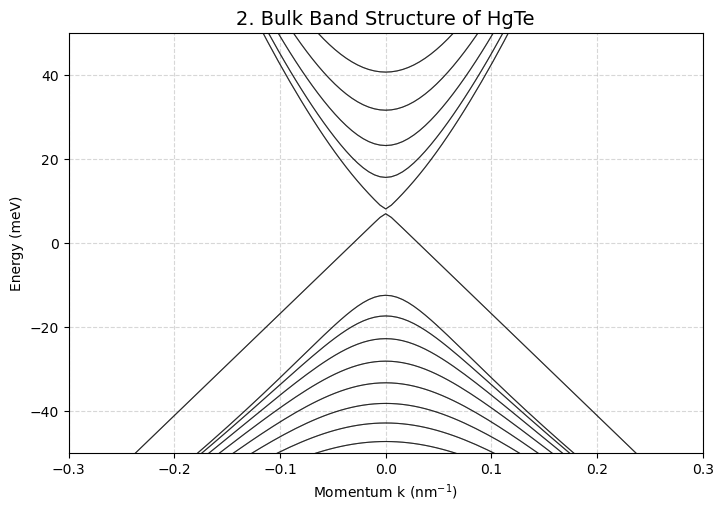

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
# Ignorar advertencias para limpieza
warnings.filterwarnings("ignore")


# 1. Configuración y parámetros
# Parámetros del material (HgTe 7.0 nm - König et al. 2008) 
A = 364.5      # meV nm
B = -686.0     # meV nm^2
D = -512.0     # meV nm^2
M = -10.0      # meV (Masa negativa -> Topológico)
C = 0.0        # meV

# Parámetros de la simulación (Geometría de Cinta)
W = 150.0      # Anchura de la cinta en nm (Reducido para ver mejor la cuantización)
a = 2.0        # Constante de red artificial (nm)
Ny = int(W / a) # Número de sitios en la red (dirección y)


# Definición correcta de Matrices de Pauli
s0 = np.eye(2)
# Sigma X: [[0, 1], [1, 0]]
sx = np.array([[0, 1], [1, 0]], dtype=complex)

# Sigma Y: [[0, -i], [i, 0]]
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)

# Sigma Z: [[1, 0], [0, -1]]
sz = np.array([[1, 0], [0, -1]], dtype=complex)


# 2. Construcción del hamiltoniano
def make_hamiltonian(kx):
    """
    Construye la matriz Hamiltoniana de Tight-Binding (4Ny x 4Ny)
    para un momento kx dado.
    """
    # Términos diagonales (On-site)
    # E(k) = C - D(kx^2 + ky^2) -> ky^2 se convierte en 2/a^2 en diferencias finitas
    # M(k) = M - B(kx^2 + ky^2)
    eps_k = C - D * (kx**2 + 2/a**2)
    m_k   = M - B * (kx**2 + 2/a**2)
    
    # Bloques 2x2 para cada espín
    # Spin UP: H = (eps + m)sz + A*kx*sx
    h_up = (eps_k * s0) + (m_k * sz) + (A * kx * sx)
    
    # Spin DOWN: H*(-k) -> Inversión temporal
    # eps y m son pares en k. El término lineal A*kx cambia de signo con k->-k.
    h_dn = (eps_k * s0) + (m_k * sz) - (A * kx * sx)
    
    # Ensamblaje del bloque on-site 4x4
    H_onsite = np.zeros((4, 4), dtype=complex)
    H_onsite[0:2, 0:2] = h_up
    H_onsite[2:4, 2:4] = h_dn
    
    # Términos de Hopping (Salto entre j y j+1)
    # Ty = (D + B*sz)/a^2 - i*A/(2a)*sy
    # Para spin down, usamos el conjugado de sy (sy* = -sy), pero el término A es A*ky*sy
    # ky -> -i d/dy. La discretización correcta lleva a:
    
    ty_up = (D * s0 + B * sz) / a**2 - 1j * A / (2*a) * sy
    ty_dn = (D * s0 + B * sz) / a**2 + 1j * A / (2*a) * sy # Nota: cambio de signo
    
    T_y = np.zeros((4, 4), dtype=complex)
    T_y[0:2, 0:2] = ty_up
    T_y[2:4, 2:4] = ty_dn
    
    # Matriz dispersa llena (Densa para simplicidad académica)
    size = 4 * Ny
    H_tot = np.zeros((size, size), dtype=complex)
    
    for i in range(Ny):
        # Diagonal
        H_tot[4*i : 4*(i+1), 4*i : 4*(i+1)] = H_onsite
        
        if i < Ny - 1:
            # Hopping derecha (i -> i+1)
            H_tot[4*i : 4*(i+1), 4*(i+1) : 4*(i+2)] = T_y
            # Hopping izquierda (i+1 -> i)
            H_tot[4*(i+1) : 4*(i+2), 4*i : 4*(i+1)] = T_y.conj().T
            
    return H_tot


# 3. Cálculo
def main():
    k_vals = np.linspace(-0.4, 0.4, 151)
    
    # Inicialización correcta de listas
    all_eigenvalues = []
    
    for k in k_vals:
        H = make_hamiltonian(k)
        # Diagonalización 
        evals, evecs = np.linalg.eigh(H)
        
        all_eigenvalues.append(evals)
        
    # Convertir a arrays numpy para facilitar el indexado
    all_eigenvalues = np.array(all_eigenvalues) # (Nk, 4Ny)
    

    # 4. Graficación
    fig = plt.figure(figsize=(18, 12))
    
    # --- GRÁFICO 1: Estructura de Bandas del Bulk (Cuantización) ---
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.set_title("2. Bulk Band Structure of HgTe", fontsize=14)
    ax1.set_ylabel("Energy (meV)")
    ax1.set_xlabel(r"Momentum k (nm$^{-1}$)")
    
    # Graficamos todas las bandas en negro sólido para ver la cuantización
    # Al reducir W a 100nm, las bandas deberían verse separadas
    for i in range(4*Ny):
        ax1.plot(k_vals, all_eigenvalues[:, i], c='k', lw=0.8, alpha=0.6)
        
    ax1.set_ylim(-50, 50)
    ax1.set_xlim(-0.3,0.3)
    ax1.grid(True, linestyle='--', alpha=0.5)

# Bloque de ejecución principal
if __name__ == "__main__":
    main()

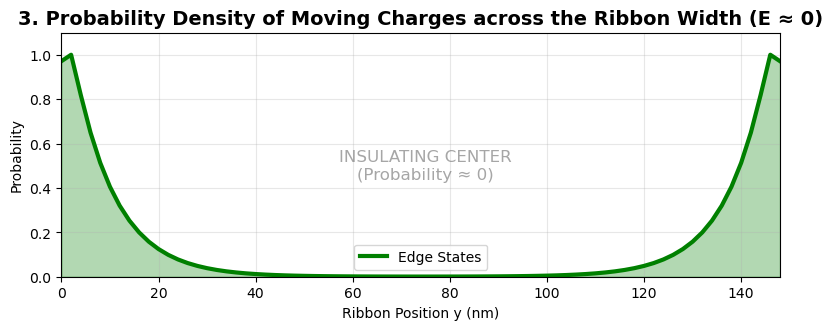

In [3]:
import kwant
import numpy as np
import sympy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")




# 1. Construcción del sistema
def make_system(W=150, a=2.0):
    """
    Construye el sistema con corrección de bordes para evitar errores de índice.
    """
    # 1. Definimos símbolos NO CONMUTATIVOS para operadores
    k_x, k_y = sympy.symbols('k_x k_y', commutative=False)
    A, B, C, D, M = sympy.symbols("A B C D M")
    
    # 2. Matrices de Pauli como objetos SymPy
    sigma_0 = sympy.eye(2)
    sigma_x = sympy.Matrix([[0, 1], [1, 0]])
    sigma_y = sympy.Matrix([[0, -1j], [1j, 0]])
    sigma_z = sympy.Matrix([[1, 0], [0, -1]])
    
    # 3. Construimos el Hamiltoniano (Modelo BHZ)
    k_sq = k_x**2 + k_y**2
    eps_k = C - D * k_sq
    m_k   = M - B * k_sq
    
    # Bloques de espín
    h_up = eps_k * sigma_0 + m_k * sigma_z + A * k_x * sigma_x - A * k_y * sigma_y
    h_dn = eps_k * sigma_0 + m_k * sigma_z - A * k_x * sigma_x - A * k_y * sigma_y

    # Matriz 4x4 completa
    hamiltonian_4x4 = sympy.diag(h_up, h_dn)
    
    # 4. Discretización
    template = kwant.continuum.discretize(hamiltonian_4x4, coords="xy", grid=a)

    # 5. Construcción del Sistema
    sym = kwant.TranslationalSymmetry((a, 0))
    syst = kwant.Builder(sym)
    

    # Usamos una pequeña tolerancia (epsilon) para evitar que, por error de redondeo,
    # se incluya un sitio extra justo en el borde W.
    def shape(site):
        (x, y) = site.pos
        # Aseguramos que y sea estrictamente menor que W con margen de seguridad
        return 0 <= y < (W - 1e-6)

    syst.fill(template, shape, (0, 0))
    
    # Parámetros numéricos
    params = dict(A=364.5, B=-686.0, D=-512.0, M=-30.0, C=0.0) # König et al. 2008
    
    return syst.finalized(), params


# 2. Cálculo
def main():
    W = 150.0 
    a = 2.0
    k_range = 0.15

    syst, params = make_system(W, a)
    
    # Extracción de matrices
    h_cell = syst.cell_hamiltonian(params=params)
    h_hop = syst.inter_cell_hopping(params=params)
    
    # --- VALIDACIÓN DE DIMENSIONES  ---
    # Calculamos cuántos sitios reales hay en la matriz Hamiltoniana
    # Cada sitio tiene 4 orbitales.
    Ny_hamiltonian = h_cell.shape[0] // 4
    
    # Obtenemos los sitios del sistema
    sites = syst.sites
    y_positions = np.array([s.pos[1] for s in sites])
    
    # Si hay discrepancia, recortamos para que coincidan (Seguridad extra)
    if len(y_positions) != Ny_hamiltonian:
        # Tomamos solo los primeros N sitios que coinciden con la matriz
        y_positions = y_positions[:Ny_hamiltonian]
    
    # Ordenamos espacialmente
    sort_idx = np.argsort(y_positions)
    y_sorted = y_positions[sort_idx]
    Ny = len(y_sorted) # Este es el Ny definitivo y seguro
    
    k_vals = np.linspace(-k_range, k_range, 201)
    evals_list = []
    color_list = [] 
    
    vecs_k0 = None
    energies_k0 = None
    idx_k0 = np.argmin(np.abs(k_vals))
    
    for i, k_real in enumerate(k_vals):
        k_adim = k_real * a
        
        # H(k) manual
        phase = np.exp(-1j * k_adim)
        h_k = h_cell + h_hop * phase + h_hop.conj().T * phase.conj()
        
        # Diagonalización
        vals, vecs = np.linalg.eigh(h_k)
        evals_list.append(vals)
        
        if i == idx_k0:
            energies_k0 = vals
            vecs_k0 = vecs
            
        # Lógica de Color (Localización)
        edge_weight = []
        limit_idx = int(Ny * 0.15)
        
        for band in range(len(vals)):
            psi = vecs[:, band]
            
            # Reshape seguro usando el Ny validado
            psi_site = psi.reshape(Ny, 4)
            psi_sorted = psi_site[sort_idx] # Ahora esto no puede fallar
            
            prob = np.sum(np.abs(psi_sorted)**2, axis=1)
            w_edge = np.sum(prob[:limit_idx]) + np.sum(prob[-limit_idx:])
            edge_weight.append(w_edge)
            
        color_list.append(edge_weight)


    # 3. Graficamos 
    fig = plt.figure(figsize=(8, 6))
    ax3 = fig.add_subplot(2, 1, 2)
    
    idx_sorted_en = np.argsort(np.abs(energies_k0))
    idx_edge_states = idx_sorted_en[:2]
    
    psi_edge_sum = np.zeros(Ny)
    for idx in idx_edge_states:
        vec = vecs_k0[:, idx].reshape(Ny, 4) 
        vec_sorted = vec[sort_idx]
        psi_edge_sum += np.sum(np.abs(vec_sorted)**2, axis=1)
        
    psi_edge_sum /= np.max(psi_edge_sum)
    
    ax3.set_title("3. Probability Density of Moving Charges across the Ribbon Width (E ≈ 0)", fontsize=14, fontweight='bold')
    ax3.plot(y_sorted, psi_edge_sum, color='green', lw=3, label='Edge States')
    ax3.fill_between(y_sorted, psi_edge_sum, color='green', alpha=0.3)
    
    ax3.set_xlabel("Ribbon Position y (nm)")
    ax3.set_ylabel("Probability")
    ax3.set_xlim(0, W-2)
    ax3.set_ylim(0, 1.1)
    
    ax3.text(W/2, 0.5, "INSULATING CENTER\n(Probability ≈ 0)", 
             ha='center', va='center', fontsize=12, color='gray', alpha=0.7)
    
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()